In [8]:
import sys
import site

print("Python executable:")
print(sys.executable)

print("\nUser site-packages:")
print(site.getusersitepackages())

print("\nSystem site-packages:")
for p in site.getsitepackages():
    print(p)

print("\nPython search paths:")
for p in sys.path:
    print(p)

Python executable:
C:\ProgramData\anaconda3\python.exe

User site-packages:
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages

System site-packages:
C:\ProgramData\anaconda3
C:\ProgramData\anaconda3\Lib\site-packages

Python search paths:
C:\ProgramData\anaconda3\python313.zip
C:\ProgramData\anaconda3\DLLs
C:\ProgramData\anaconda3\Lib
C:\ProgramData\anaconda3

C:\ProgramData\anaconda3\Lib\site-packages
C:\ProgramData\anaconda3\Lib\site-packages\win32
C:\ProgramData\anaconda3\Lib\site-packages\win32\lib
C:\ProgramData\anaconda3\Lib\site-packages\Pythonwin


In [12]:
import pandas as pd
import numpy as np
from faker import Faker
import random

# Initialize Faker
fake = Faker()
Faker.seed(42)
np.random.seed(42)
random.seed(42)

NUM_RECORDS = 10000

countries = [
    "Ghana", "Nigeria", "Kenya", "South Africa",
    "USA", "UK", "Canada"
]

membership_levels = [
    "Bronze",
    "Silver",
    "Gold",
    "Platinum"
]

devices = [
    "Desktop",
    "Mobile",
    "Tablet"
]

categories = [
    "Electronics",
    "Fashion",
    "Beauty",
    "Groceries",
    "Sports",
    "Books",
    "Home & Kitchen"
]

payment_methods = [
    "Credit Card",
    "Debit Card",
    "Mobile Money",
    "PayPal",
    "Bank Transfer"
]

rows = []

for customer_id in range(1, NUM_RECORDS + 1):

    age = np.random.randint(18, 66)

    gender = random.choice(["Male", "Female"])

    country = random.choice(countries)

    membership = random.choices(
        membership_levels,
        weights=[40,30,20,10],
        k=1
    )[0]

    registration_date = fake.date_between(
        start_date="-5y",
        end_date="-30d"
    )

    last_login = fake.date_between(
        start_date=registration_date,
        end_date="today"
    )

    device = random.choice(devices)

    category = random.choice(categories)

    price = round(np.random.uniform(10,1200),2)

    quantity = np.random.randint(1,6)

    total_purchase = round(price * quantity,2)

    visits = np.random.poisson(25)

    session_duration = round(
        np.random.uniform(2,40),2
    )

    cart_abandoned = random.choices(
        ["Yes","No"],
        weights=[25,75],
        k=1
    )[0]

    discount_used = random.choices(
        ["Yes","No"],
        weights=[55,45],
        k=1
    )[0]

    payment = random.choice(payment_methods)

    satisfaction = np.random.randint(1,6)

    clv = round(
        total_purchase * np.random.uniform(2,12),
        2
    )

    churn_probability = (
        (visits < 10) * 0.35 +
        (satisfaction <= 2) * 0.35 +
        (cart_abandoned == "Yes") * 0.20 +
        (membership == "Bronze") * 0.10
    )

    churn = np.random.binomial(
        1,
        min(churn_probability,0.95)
    )

    rows.append([
        customer_id,
        age,
        gender,
        country,
        membership,
        registration_date,
        last_login,
        device,
        category,
        price,
        quantity,
        total_purchase,
        visits,
        session_duration,
        cart_abandoned,
        discount_used,
        payment,
        satisfaction,
        clv,
        churn
    ])

columns = [
    "CustomerID",
    "Age",
    "Gender",
    "Country",
    "Membership",
    "RegistrationDate",
    "LastLogin",
    "Device",
    "ProductCategory",
    "ProductPrice",
    "Quantity",
    "TotalPurchase",
    "WebsiteVisits",
    "SessionDuration",
    "CartAbandoned",
    "DiscountUsed",
    "PaymentMethod",
    "CustomerSatisfaction",
    "CustomerLifetimeValue",
    "Churn"
]

df = pd.DataFrame(rows, columns=columns)

df.to_csv("ecommerce_customers.csv", index=False)

print(df.head())

print()

print(df.shape)

print("\nDataset saved as ecommerce_customers.csv")

   CustomerID  Age Gender       Country Membership RegistrationDate  \
0           1   56   Male         Ghana       Gold       2022-06-12   
1           2   57   Male           USA     Silver       2023-11-03   
2           3   42   Male            UK     Silver       2023-05-26   
3           4   20   Male            UK     Silver       2022-05-16   
4           5   19   Male  South Africa     Bronze       2026-02-20   

    LastLogin   Device ProductCategory  ProductPrice  Quantity  TotalPurchase  \
0  2022-07-20  Desktop         Fashion        957.89         3        2873.67   
1  2024-11-17  Desktop     Electronics        852.61         5        4263.05   
2  2023-12-28   Tablet       Groceries        356.56         3        1069.68   
3  2025-04-01   Mobile         Fashion       1033.33         5        5166.65   
4  2026-03-08   Mobile          Sports        824.24         4        3296.96   

   WebsiteVisits  SessionDuration CartAbandoned DiscountUsed  PaymentMethod  \
0      

In [13]:
# ==========================================
# STEP 2: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ecommerce_customers.csv")

print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(df.info())

print("\n")

print("="*60)
print("FIRST FIVE ROWS")
print("="*60)

print(df.head())

print("\n")

print("="*60)
print("LAST FIVE ROWS")
print("="*60)

print(df.tail())

print("\n")

print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

print(df.describe())

print("\n")

print("="*60)
print("MISSING VALUES")
print("="*60)

print(df.isnull().sum())

print("\n")

print("="*60)
print("DUPLICATE RECORDS")
print("="*60)

print(df.duplicated().sum())

print("\n")

print("="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             10000 non-null  int64  
 1   Age                    10000 non-null  int64  
 2   Gender                 10000 non-null  object 
 3   Country                10000 non-null  object 
 4   Membership             10000 non-null  object 
 5   RegistrationDate       10000 non-null  object 
 6   LastLogin              10000 non-null  object 
 7   Device                 10000 non-null  object 
 8   ProductCategory        10000 non-null  object 
 9   ProductPrice           10000 non-null  float64
 10  Quantity               10000 non-null  int64  
 11  TotalPurchase          10000 non-null  float64
 12  WebsiteVisits          10000 non-null  int64  
 13  SessionDuration        10000 non-null  float64
 14  CartAbandoned          10000 non-nu

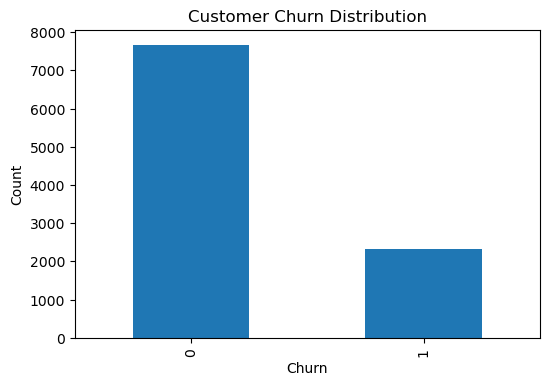

In [14]:
plt.figure(figsize=(6,4))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

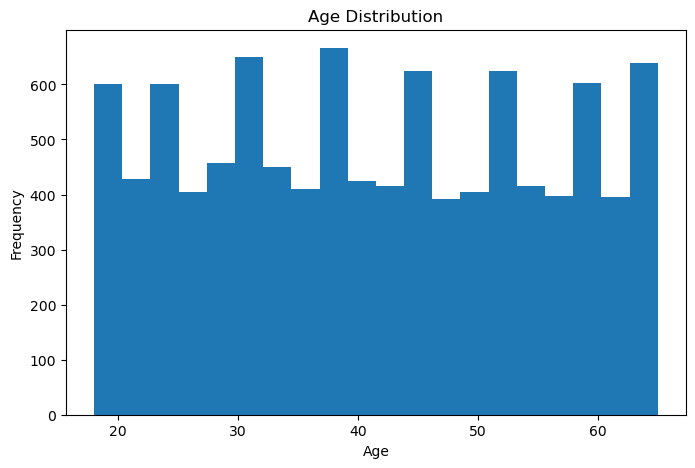

In [4]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

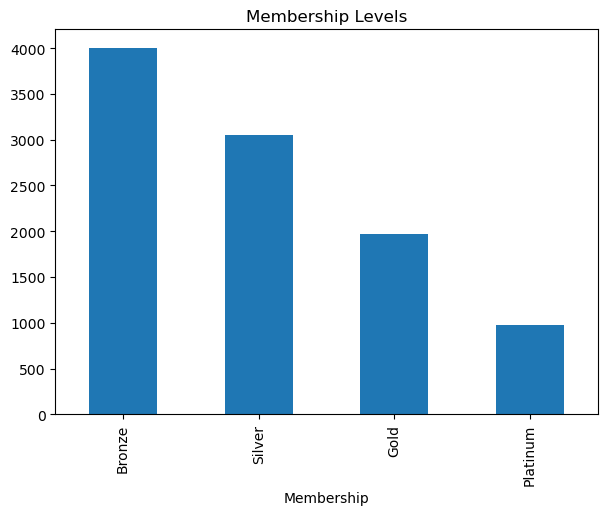

In [5]:
plt.figure(figsize=(7,5))

df["Membership"].value_counts().plot(kind="bar")

plt.title("Membership Levels")

plt.show()

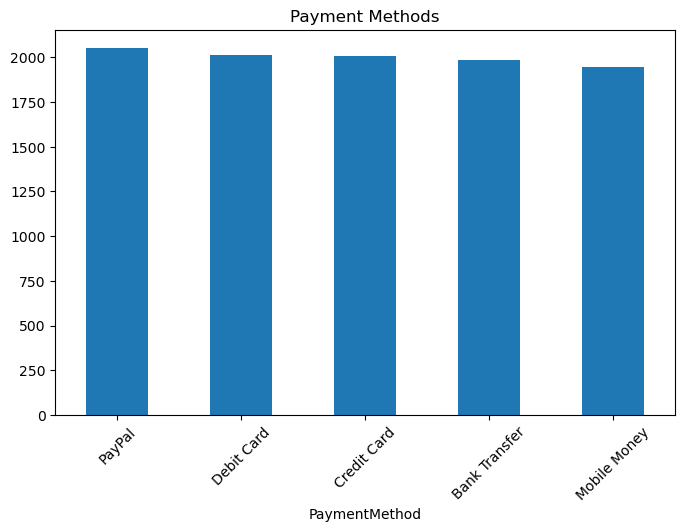

In [6]:
plt.figure(figsize=(8,5))

df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Payment Methods")

plt.xticks(rotation=45)

plt.show()

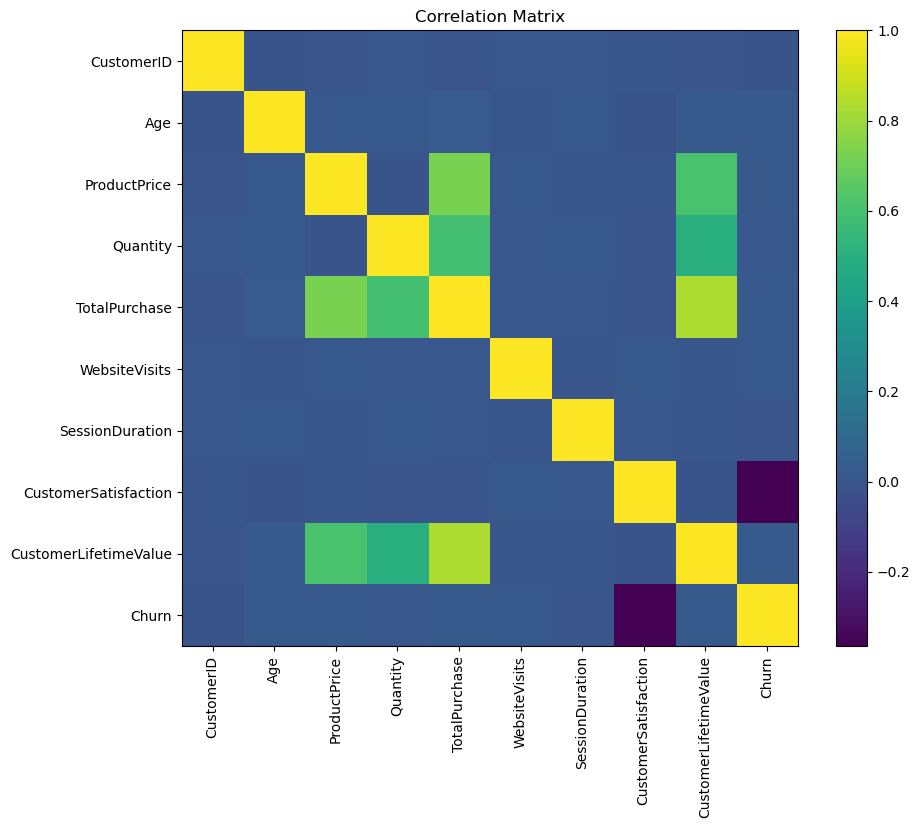

In [7]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [8]:
print(df["Churn"].value_counts(normalize=True)*100)

Churn
0    76.75
1    23.25
Name: proportion, dtype: float64


In [9]:
# ==========================================
# STEP 3: DATA CLEANING & FEATURE ENGINEERING
# ==========================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df = pd.read_csv("ecommerce_customers.csv")

# ------------------------------------------
# 1. Convert dates to datetime
# ------------------------------------------
df["RegistrationDate"] = pd.to_datetime(df["RegistrationDate"])
df["LastLogin"] = pd.to_datetime(df["LastLogin"])

print("Date conversion completed.")

# ------------------------------------------
# 2. Create Customer Tenure (days)
# ------------------------------------------
today = pd.Timestamp.today()

df["CustomerTenure"] = (today - df["RegistrationDate"]).dt.days

print("CustomerTenure created.")

# ------------------------------------------
# 3. Create Average Order Value
# ------------------------------------------
df["AverageOrderValue"] = (
    df["TotalPurchase"] / df["Quantity"]
).round(2)

print("AverageOrderValue created.")

# ------------------------------------------
# 4. Create Engagement Score
# ------------------------------------------
df["EngagementScore"] = (
    df["WebsiteVisits"] * 0.4 +
    df["SessionDuration"] * 0.6
).round(2)

print("EngagementScore created.")

# ------------------------------------------
# 5. Days Since Last Login
# ------------------------------------------
df["DaysSinceLastLogin"] = (
    today - df["LastLogin"]
).dt.days

print("DaysSinceLastLogin created.")

# ------------------------------------------
# 6. Encode categorical variables
# ------------------------------------------
categorical_columns = [
    "Gender",
    "Country",
    "Membership",
    "Device",
    "ProductCategory",
    "CartAbandoned",
    "DiscountUsed",
    "PaymentMethod"
]

encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

print("Categorical variables encoded.")

# ------------------------------------------
# 7. Standardize numerical features
# ------------------------------------------
scaler = StandardScaler()

numeric_features = [
    "Age",
    "ProductPrice",
    "Quantity",
    "TotalPurchase",
    "WebsiteVisits",
    "SessionDuration",
    "CustomerSatisfaction",
    "CustomerLifetimeValue",
    "CustomerTenure",
    "AverageOrderValue",
    "EngagementScore",
    "DaysSinceLastLogin"
]

df[numeric_features] = scaler.fit_transform(
    df[numeric_features]
)

print("Numerical features standardized.")

# ------------------------------------------
# Final Dataset Preview
# ------------------------------------------
print("\nDataset Shape:")
print(df.shape)

print("\nFirst Five Rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

# Save processed dataset
df.to_csv("processed_ecommerce_customers.csv", index=False)

print("\nProcessed dataset saved as 'processed_ecommerce_customers.csv'")

Date conversion completed.
CustomerTenure created.
AverageOrderValue created.
EngagementScore created.
DaysSinceLastLogin created.
Categorical variables encoded.
Numerical features standardized.

Dataset Shape:
(10000, 24)

First Five Rows:
   CustomerID       Age  Gender  Country  Membership RegistrationDate  \
0           1  1.060546       1        1           1       2022-06-12   
1           2  1.133060       1        6           3       2023-11-03   
2           3  0.045357       1        5           3       2023-05-26   
3           4 -1.549940       1        5           3       2022-05-16   
4           5 -1.622453       1        4           0       2026-02-20   

   LastLogin  Device  ProductCategory  ProductPrice  ...  CartAbandoned  \
0 2022-07-20       0                3      1.011833  ...              1   
1 2024-11-17       0                2      0.707267  ...              1   
2 2023-12-28       2                4     -0.727765  ...              1   
3 2025-04-01       1

In [10]:
new_features = [
    "CustomerTenure",
    "AverageOrderValue",
    "EngagementScore",
    "DaysSinceLastLogin"
]

print(df[new_features].head())

   CustomerTenure  AverageOrderValue  EngagementScore  DaysSinceLastLogin
0        1.066144           1.011833         0.040127            2.441487
1        0.086067           0.707267        -1.360318            0.323929
2        0.396071          -0.727765         1.449344            1.132632
3        1.118132           1.230075         1.402565           -0.011994
4       -1.531349           0.625195        -1.972831           -0.860510


In [11]:
# ==========================================
# STEP 4: CUSTOMER CHURN PREDICTION
# ==========================================

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load processed dataset
df = pd.read_csv("processed_ecommerce_customers.csv")

# Separate Features and Target
X = df.drop(columns=["CustomerID",
                     "RegistrationDate",
                     "LastLogin",
                     "Churn"])

y = df["Churn"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Feature Matrix Shape: (10000, 20)
Target Shape: (10000,)
Training samples: 8000
Testing samples: 2000


In [12]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )

}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    roc = roc_auc_score(y_test, probabilities)

    cv = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    ).mean()

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc,
        cv
    ])

results_df = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "Cross Validation"
    ]

)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC  \
0  Logistic Regression    0.7840   0.577465  0.264516  0.362832  0.793450   
1        Decision Tree    0.7155   0.392562  0.408602  0.400421  0.608536   
2        Random Forest    0.7695   0.508621  0.253763  0.338594  0.810394   

   Cross Validation  
0            0.7845  
1            0.7215  
2            0.7762  


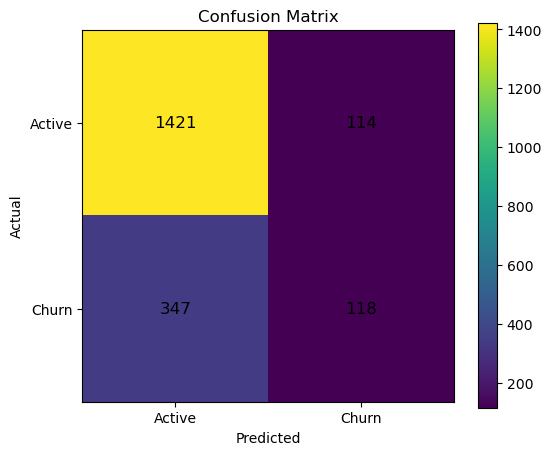

In [13]:
import matplotlib.pyplot as plt

best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Active","Churn"])

plt.yticks([0,1],["Active","Churn"])

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=12
        )

plt.show()

In [14]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                  Feature  Importance
14   CustomerSatisfaction    0.171080
16         CustomerTenure    0.067581
15  CustomerLifetimeValue    0.065513
19     DaysSinceLastLogin    0.064690
10        SessionDuration    0.064131
18        EngagementScore    0.063881
8           TotalPurchase    0.062800
17      AverageOrderValue    0.059806
6            ProductPrice    0.058213
0                     Age    0.056183


In [15]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      1535
           1       0.51      0.25      0.34       465

    accuracy                           0.77      2000
   macro avg       0.66      0.59      0.60      2000
weighted avg       0.74      0.77      0.74      2000



In [16]:
import joblib

joblib.dump(best_model,"customer_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


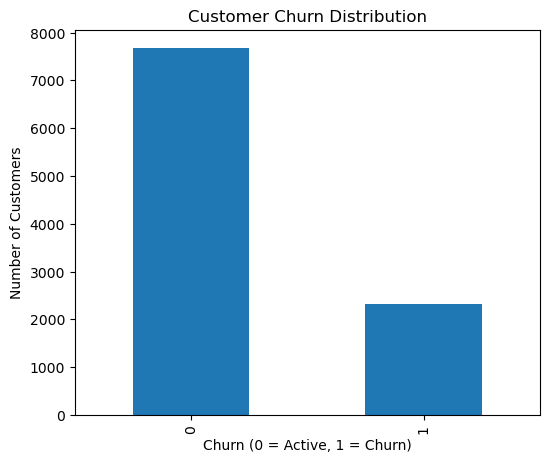

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load processed data
df = pd.read_csv("processed_ecommerce_customers.csv")

plt.figure(figsize=(6,5))

df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = Active, 1 = Churn)")
plt.ylabel("Number of Customers")

plt.show()

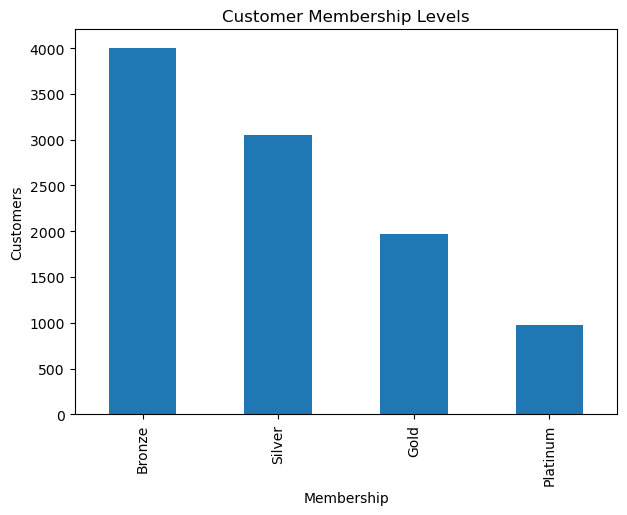

In [18]:
membership = pd.read_csv("ecommerce_customers.csv")

plt.figure(figsize=(7,5))

membership["Membership"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Membership Levels")
plt.xlabel("Membership")
plt.ylabel("Customers")

plt.show()

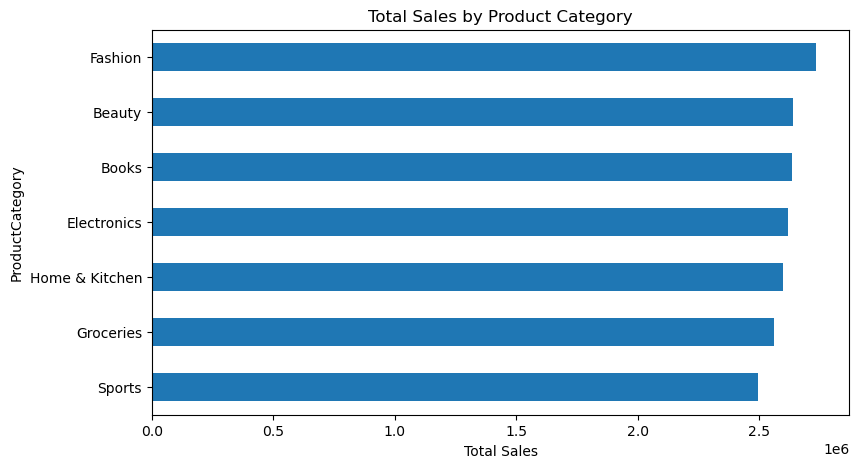

In [19]:
sales = pd.read_csv("ecommerce_customers.csv")

category_sales = sales.groupby(
    "ProductCategory"
)["TotalPurchase"].sum()

plt.figure(figsize=(9,5))

category_sales.sort_values().plot(
    kind="barh"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales")

plt.show()

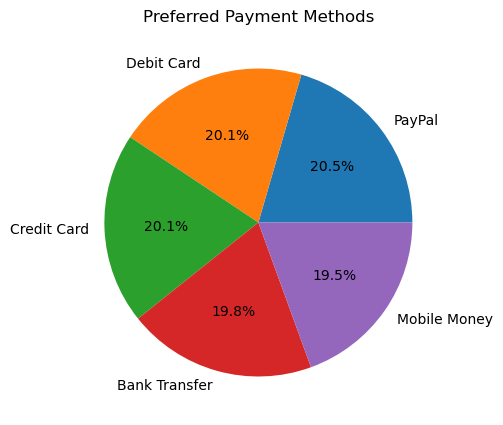

In [20]:
plt.figure(figsize=(8,5))

sales["PaymentMethod"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Preferred Payment Methods")

plt.show()

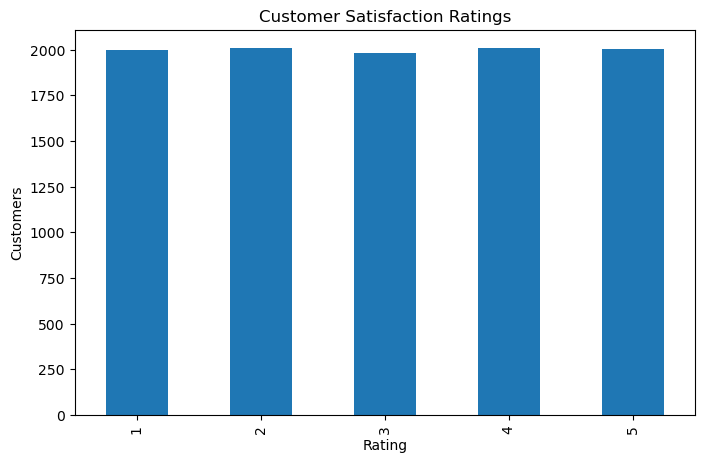

In [21]:
plt.figure(figsize=(8,5))

sales["CustomerSatisfaction"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Customer Satisfaction Ratings")

plt.xlabel("Rating")

plt.ylabel("Customers")

plt.show()

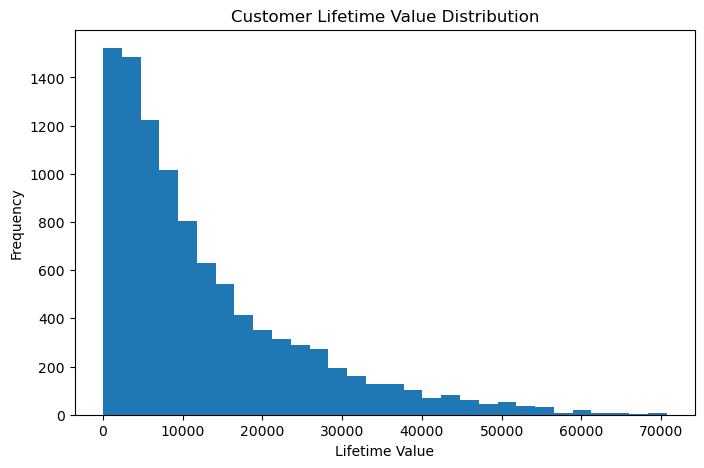

In [22]:
plt.figure(figsize=(8,5))

plt.hist(
    sales["CustomerLifetimeValue"],
    bins=30
)

plt.title("Customer Lifetime Value Distribution")

plt.xlabel("Lifetime Value")

plt.ylabel("Frequency")

plt.show()

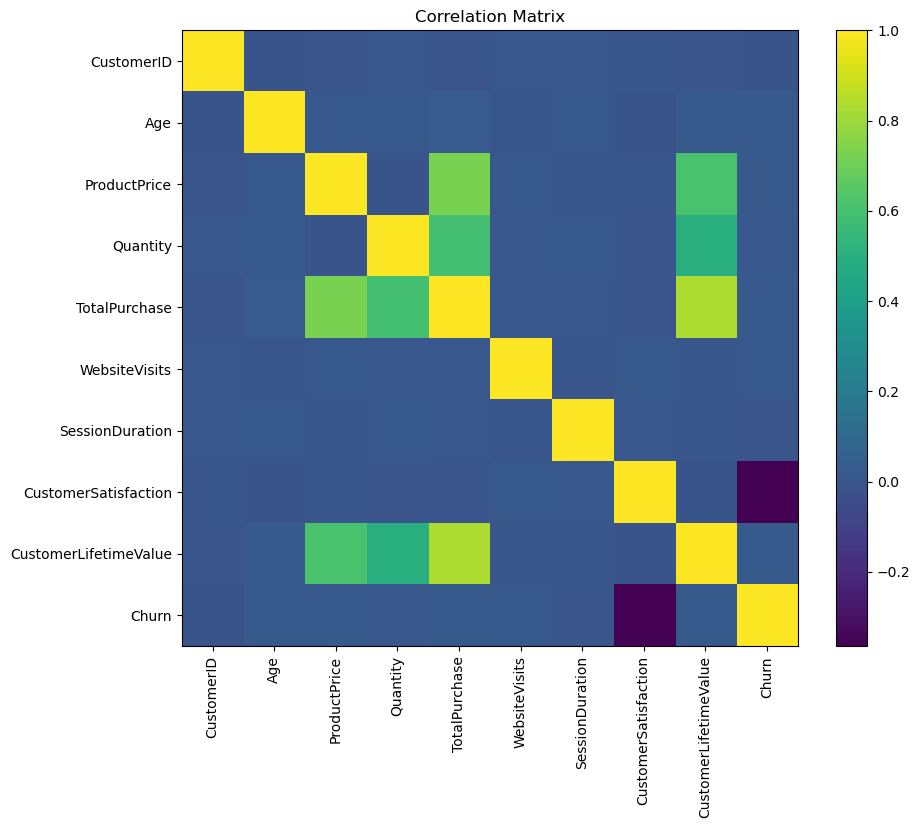

In [23]:
import numpy as np

numeric = sales.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# E-commerce Customer Analytics Project

## Objective

Analyze customer behavior using synthetic e-commerce data to identify patterns, predict churn, and generate business insights.

## Project Structure

├── ecommerce_customers.csv
├── processed_ecommerce_customers.csv
├── Ecommerce_Analysis.ipynb
├── customer_churn_model.pkl
├── Final_Report.docx
├── Presentation.pptx
├── README.md
└── requirements.txt

## Libraries

pandas
numpy
matplotlib
scikit-learn
joblib
faker

## Run

1. Generate dataset.
2. Perform EDA.
3. Clean and engineer features.
4. Train machine learning models.
5. Generate business insights.
6. Save the trained model.


In [ ]:
pandas
numpy
matplotlib
scikit-learn
joblib
faker